<a href="https://colab.research.google.com/github/EMaxturn/Proof-of-Concept-Transactional-Fraud-Detection/blob/main/Proof_of_Concept_Transactional_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Proof of Concept - Transactional Fraud Detection

### 1. Introduction
- In this example, we will use the real-world 'creditcard.csv' dataset to walk through a basic data science workflow for fraud detection.

Dataset shape: (284807, 31)

Dataset summary statistics:
                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.168375e-15  3.416908e-16 -1.379537e-15  2.074095e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   9.604066e-16  1.487313e-15 -5.556467e-16  1.213481e-16 -2

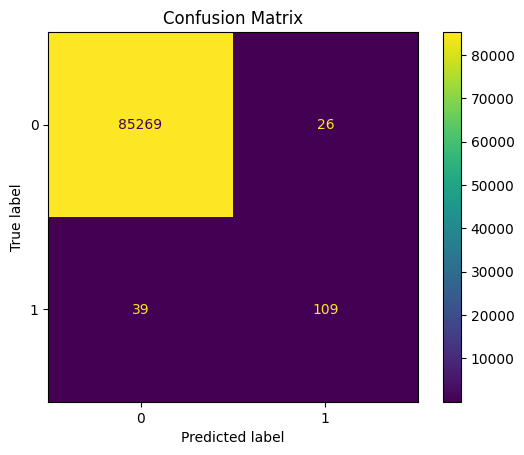

In [ ]:
# 1. Library Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

# 2. Load the Dataset
df = pd.read_csv('creditcard.csv')

# Quick look at the data
print("Dataset shape:", df.shape)
print("\nDataset summary statistics:")
print(df.describe())

# Check class distribution
print("\nClass distribution:")
print(df['Class'].value_counts(normalize=True))

# 3. Prepare the Data
# Drop 'Time' feature, use 'Amount' and PCA features
X = df.drop(['Time', 'Class'], axis=1)
y = df['Class']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 4. Build a Simple Decision Tree Model
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# 5. Evaluate the Model
y_pred = model.predict(X_test)

print("\nModel Evaluation Metrics:")
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title('Confusion Matrix')
plt.show()

 Building a Transactional Fraud Detection Model

---

## 📚 Introduction

In this proof of concept, we will build and improve a fraud detection model using the real-world `creditcard.csv` dataset.

We will start with a simple Decision Tree model to walk through a basic workflow.  
We'll then expand the model by:

- Changing the Train/Test split
- Replacing the Decision Tree with a Random Forest Classifier
- Tuning hyperparameters (`n_estimators` and `max_depth`)
- Evaluating model performance using Precision, Recall, F1-Score, and ROC-AUC
- Comparing the performance of the two models

---

# Overview

---

| Task | Description | |
|:---|:---|:---|
| Train/Test Split | Change the Train/Test split from 70/30 to 80/20. | |
| Model Replacement | Replace the Decision Tree model with a Random Forest Classifier. | |
| Model Configuration | Set Random Forest parameters:<br>- `n_estimators = 200`<br>- `max_depth = 5`<br>- `random_state = 42` |  |
| Model Evaluation | Predict on the test set and report:<br>- Precision<br>- Recall<br>- F1-Score<br>- ROC-AUC | 20 |
| Model Comparison | Compare Decision Tree and Random Forest results:<br>- Discuss changes in Precision and Recall<br>- Discuss trade-offs in performance ||
| Data Balancing | Balance the training data using random undersampling.
| Hyperparameter Tuning | Tune:<br>- `n_estimators` (e.g., 100, 200, 300)<br>- `max_depth` (e.g., 3, 5, 7)
| Analysis | Discuss which parameter settings produced the best Precision and Recall.

---



Random Forest Classifier

Dataset shape: (284807, 31)

Dataset summary statistics:
                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.168375e-15  3.416908e-16 -1.379537e-15  2.074095e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   9.604066e-16  1.487313e-15 -5.556467e-16  1.213481e-16 -2

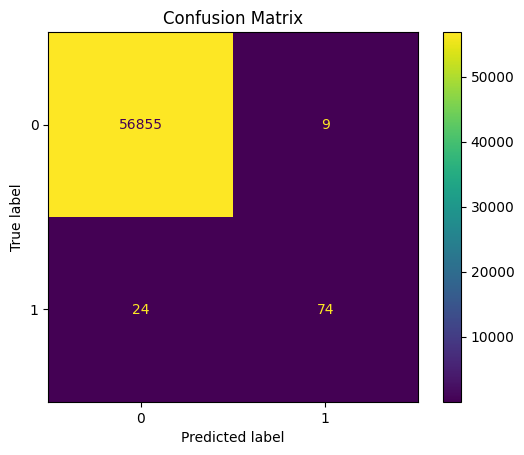

In [ ]:
# 2. Library Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

# 3. Load the Dataset
df = pd.read_csv('creditcard.csv')

# Quick look at the data
print("Dataset shape:", df.shape)
print("\nDataset summary statistics:")
print(df.describe())

# Check class distribution
print("\nClass distribution:")
print(df['Class'].value_counts(normalize=True))

# 4. Prepare the Data
# Drop 'Time' feature, use 'Amount' and PCA features
X = df.drop(['Time', 'Class'], axis=1)
y = df['Class']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5. Build a Simple Decision Tree Model
model = RandomForestClassifier(random_state=42, max_depth=5, n_estimators=200)
model.fit(X_train, y_train)

# 6. Evaluate the Model
y_pred = model.predict(X_test)

print("\nModel Evaluation Metrics:")
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title('Confusion Matrix')
plt.show()


Decison Tree for Comparison

Dataset shape: (284807, 31)

Dataset summary statistics:
                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.168375e-15  3.416908e-16 -1.379537e-15  2.074095e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   9.604066e-16  1.487313e-15 -5.556467e-16  1.213481e-16 -2

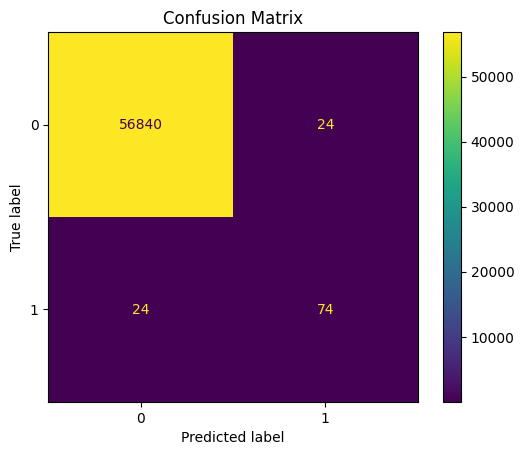

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

# 3. Load the Dataset
df = pd.read_csv('creditcard.csv')

# Quick look at the data
print("Dataset shape:", df.shape)
print("\nDataset summary statistics:")
print(df.describe())

# Check class distribution
print("\nClass distribution:")
print(df['Class'].value_counts(normalize=True))

# 4. Prepare the Data
# Drop 'Time' feature, use 'Amount' and PCA features
X = df.drop(['Time', 'Class'], axis=1)
y = df['Class']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5. Build a Simple Decision Tree Model
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# 6. Evaluate the Model
y_pred = model.predict(X_test)

print("\nModel Evaluation Metrics:")
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title('Confusion Matrix')
plt.show()

Given that the decision tree's false negatives and false positives are both 24, the precision, recall, and F1 scores of the  produce the same 0.7551020408163265 value. The Decision tree clearly underperforms the Random Forest, for which the Precision score is 0.891566265060241, the Recall is 0.7551020408163265, and the F1 is 0.8176795580110497. The Random Forest correctly classifies 15 more smooth transactions that the Decision Forest flagged falsely as fraud. It is also more balanced between Precision and Recall. The two models also overlook the same amount of false negatives, which is notable from a business risk perspective.

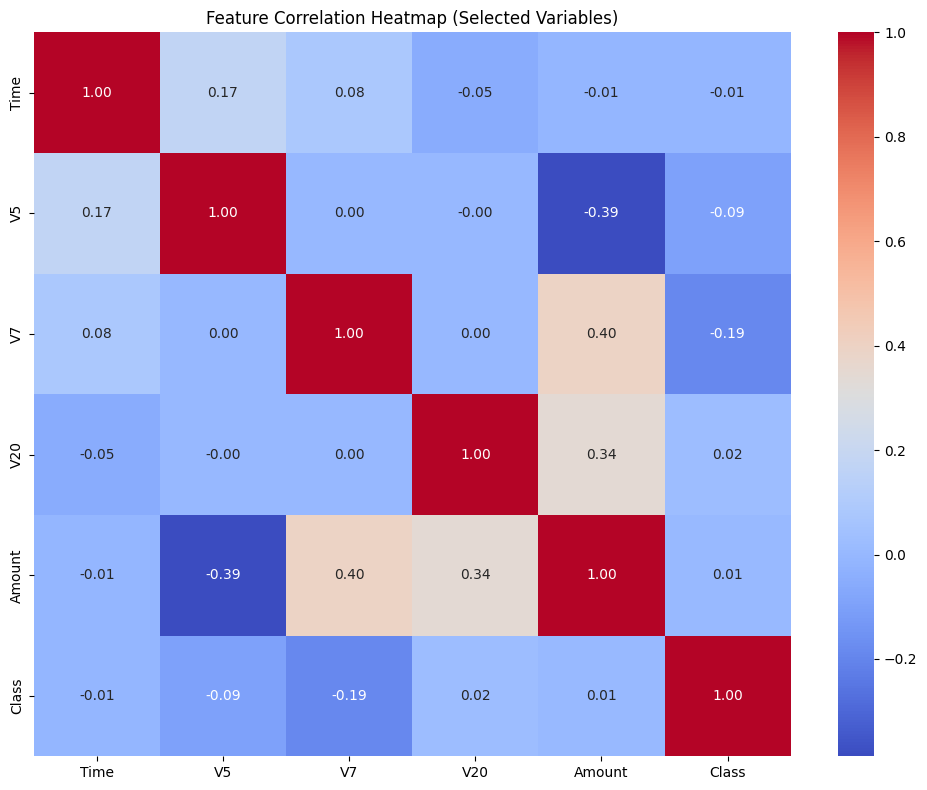

In [ ]:
# Create correlation heatmap with selected variables
columns_to_keep = []
for col in df.columns:
    # Keep the column if it's not a V-column OR if it's one of our selected V columns
    if not (col.startswith('V') and col[1:].isdigit()) or col in ['V7', 'V5', 'V20']:
        columns_to_keep.append(col)

filtered_df = df[columns_to_keep]

# Create correlation heatmap with selected variables
plt.figure(figsize=(10, 8))
correlation_matrix = filtered_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap (Selected Variables)")
plt.tight_layout()
plt.show()

Random Forest Hyperparameter Tuning for n_estimators (100)

Below we see that using less trees outperforms the Random Forest with 200 trees as well as the Decision Tree models above. It is likely that the model overfits beyond 100 trees, memorizing noise and not meaningful patterns in the data. Notably, the Precision score indicates a slight drop in false positives which is good, but also one additional false negative.

Dataset shape: (284807, 31)

Dataset summary statistics:
                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.168375e-15  3.416908e-16 -1.379537e-15  2.074095e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   9.604066e-16  1.487313e-15 -5.556467e-16  1.213481e-16 -2

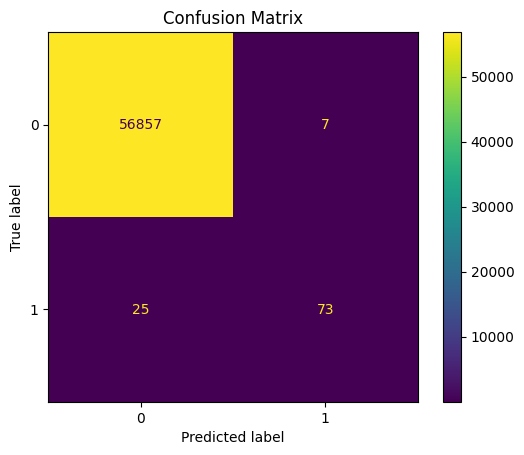

In [ ]:
# 3. Load the Dataset
df = pd.read_csv('creditcard.csv')

# Quick look at the data
print("Dataset shape:", df.shape)
print("\nDataset summary statistics:")
print(df.describe())

# Check class distribution
print("\nClass distribution:")
print(df['Class'].value_counts(normalize=True))

# 4. Prepare the Data
# Drop 'Time' feature, use 'Amount' and PCA features
X = df.drop(['Time', 'Class'], axis=1)
y = df['Class']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5. Build a Simple Decision Tree Model
model = RandomForestClassifier(random_state=42, max_depth=5, n_estimators=100)
model.fit(X_train, y_train)

# 6. Evaluate the Model
y_pred = model.predict(X_test)

print("\nModel Evaluation Metrics:")
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title('Confusion Matrix')
plt.show()

Random Forest n_estimators (300)

The scores below support the conclusion drawn above that using beyond 100 trees likely causes overfitting. The 300 and 200 tree models show poorer performance than the model with 100 trees. This is reflected in the Precision Scores. There is some evidence of the precision/recall tradeoff, where models with more false negatives have less false postives, and vice versa.

Dataset shape: (284807, 31)

Dataset summary statistics:
                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.168375e-15  3.416908e-16 -1.379537e-15  2.074095e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   9.604066e-16  1.487313e-15 -5.556467e-16  1.213481e-16 -2

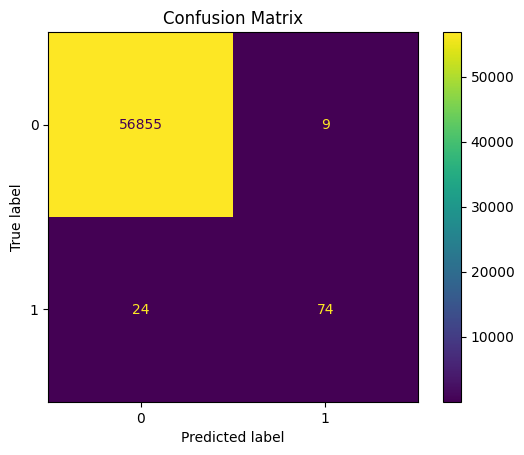

In [ ]:
# 3. Load the Dataset
df = pd.read_csv('creditcard.csv')

# Quick look at the data
print("Dataset shape:", df.shape)
print("\nDataset summary statistics:")
print(df.describe())

# Check class distribution
print("\nClass distribution:")
print(df['Class'].value_counts(normalize=True))

# 4. Prepare the Data
# Drop 'Time' feature, use 'Amount' and PCA features
X = df.drop(['Time', 'Class'], axis=1)
y = df['Class']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5. Build a Simple Decision Tree Model
model = RandomForestClassifier(random_state=42, max_depth=5, n_estimators=300)
model.fit(X_train, y_train)

# 6. Evaluate the Model
y_pred = model.predict(X_test)

print("\nModel Evaluation Metrics:")
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title('Confusion Matrix')
plt.show()

Random Forest with 100 trees, max depth 3.

This model shows very poor performance compared to the others we have seen. Clearly the trees require greater  depth in order to capture nuances in the data indicative of fraud.

Dataset shape: (284807, 31)

Dataset summary statistics:
                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.168375e-15  3.416908e-16 -1.379537e-15  2.074095e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   9.604066e-16  1.487313e-15 -5.556467e-16  1.213481e-16 -2

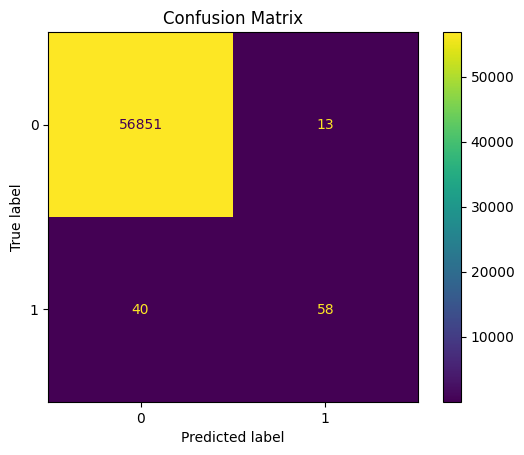

In [ ]:

# Quick look at the data
print("Dataset shape:", df.shape)
print("\nDataset summary statistics:")
print(df.describe())

# Check class distribution
print("\nClass distribution:")
print(df['Class'].value_counts(normalize=True))

# 4. Prepare the Data
# Drop 'Time' feature, use 'Amount' and PCA features
X = df.drop(['Time', 'Class'], axis=1)
y = df['Class']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5. Build a Simple Decision Tree Model
model = RandomForestClassifier(random_state=42, max_depth=3, n_estimators=100)
model.fit(X_train, y_train)

# 6. Evaluate the Model
y_pred = model.predict(X_test)

print("\nModel Evaluation Metrics:")
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title('Confusion Matrix')
plt.show()

Random Forest with 100 trees, max depth 7

The model below shows the best performance of any so far. It has the highest Precision score of .95, as well as a Recall of .775, indicating for our data a few deep trees detect fraud better than many shallow ones.

Dataset shape: (284807, 31)

Dataset summary statistics:
                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.168375e-15  3.416908e-16 -1.379537e-15  2.074095e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   9.604066e-16  1.487313e-15 -5.556467e-16  1.213481e-16 -2

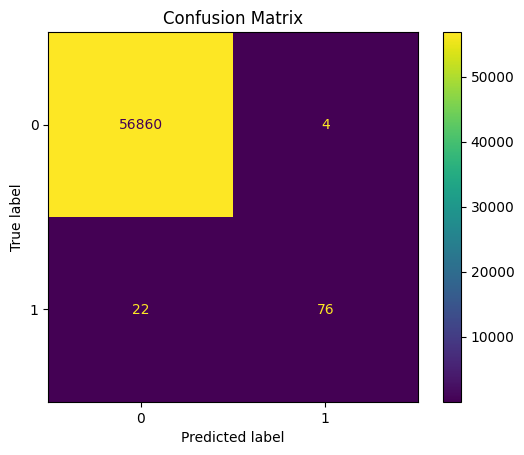

In [ ]:

# Quick look at the data
print("Dataset shape:", df.shape)
print("\nDataset summary statistics:")
print(df.describe())

# Check class distribution
print("\nClass distribution:")
print(df['Class'].value_counts(normalize=True))

# 4. Prepare the Data
# Drop 'Time' feature, use 'Amount' and PCA features
X = df.drop(['Time', 'Class'], axis=1)
y = df['Class']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5. Build a Simple Decision Tree Model
model = RandomForestClassifier(random_state=42, max_depth=7, n_estimators=100)
model.fit(X_train, y_train)

# 6. Evaluate the Model
y_pred = model.predict(X_test)

print("\nModel Evaluation Metrics:")
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title('Confusion Matrix')
plt.show()

Random Undersampling

Here I take our initial 200 trees Random Forest model and apply imblearns 'RandomUnderSampler' module. We see that after equalizing the amount of fraud versus non-fraud in the training set the module's amount of false positives skyrockets, whereas the recall greatly improves. The model shows excessive scrutiny that in practice would significantly impact customer satisfaction.


Class distribution after undersampling:
0    0.5
1    0.5
Name: Class, dtype: float64

Model Evaluation Metrics after undersampling:
Precision: 0.06816421378776143
Recall: 0.8979591836734694
F1-Score: 0.12670986321094313
ROC-AUC: 0.9384017218311071


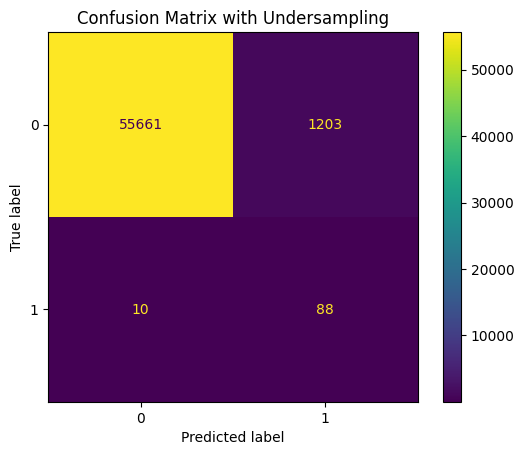

In [ ]:

from imblearn.under_sampling import RandomUnderSampler


undersampler = RandomUnderSampler(random_state=42)
X_train_resampled, y_train_resampled = undersampler.fit_resample(X_train, y_train)


print("\nClass distribution after undersampling:")
print(pd.Series(y_train_resampled).value_counts(normalize=True))


model = RandomForestClassifier(random_state=42, max_depth=5, n_estimators=200)
model.fit(X_train_resampled, y_train_resampled)


y_pred = model.predict(X_test)

print("\nModel Evaluation Metrics after undersampling:")
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title('Confusion Matrix with Undersampling')
plt.show()